# Fase 2 - Limpieza de datos

**Entrada:** `data/olist.db` (datos originales, sin tocar).
**Salida:** tres tablas limpias en `data/clean/`:

| Archivo | Una fila es... | Para qué |
|---|---|---|
| `pedidos.csv` | un pedido entregado | KPIs, segmentación y modelo |
| `items.csv` | un producto dentro de un pedido | análisis por categoría |
| `pagos.csv` | un pago de un pedido | análisis de métodos de pago |

Cada decisión de limpieza queda apuntada en un registro con las filas antes y después.

In [1]:
import sqlite3

import matplotlib.pyplot as plt
import pandas as pd

con = sqlite3.connect("../data/olist.db")

# Columnas de fecha: en la base de datos están guardadas como texto
fechas = ["order_purchase_timestamp", "order_approved_at", "order_delivered_carrier_date",
          "order_delivered_customer_date", "order_estimated_delivery_date"]

orders = pd.read_sql("SELECT * FROM orders", con, parse_dates=fechas)
customers = pd.read_sql("SELECT * FROM customers", con)
items = pd.read_sql("SELECT * FROM order_items", con)
payments = pd.read_sql("SELECT * FROM order_payments", con)
reviews = pd.read_sql("SELECT * FROM order_reviews", con, parse_dates=["review_answer_timestamp"])
products = pd.read_sql("SELECT * FROM products", con)
traduccion = pd.read_sql("SELECT * FROM product_category_name_translation", con)
con.close()

# Registro de limpieza: una línea por cada decisión
registro = []

def apuntar(paso, antes, despues, motivo):
    registro.append({"paso": paso, "filas_antes": antes, "filas_despues": despues,
                     "eliminadas": antes - despues, "motivo": motivo})

## 1. Tipos de datos
`parse_dates` ya ha convertido las fechas al leer. Lo comprobamos: deben salir como `datetime64`.

In [2]:
orders.dtypes

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

## 2. Pedidos: qué entra en el análisis

Tres filtros, en este orden:
1. **Periodo** enero 2017 - agosto 2018. Los meses de fuera tienen entre 1 y 324 pedidos y distorsionan cualquier evolución.
2. **Solo pedidos entregados.** Un pedido cancelado no genera ingreso ni valoración fiable.
3. **Entregados sin fecha de entrega**: dato contradictorio, se excluyen.

In [3]:
pedidos = orders.copy()

n = len(pedidos)
pedidos = pedidos[pedidos["order_purchase_timestamp"].between("2017-01-01", "2018-08-31 23:59:59")]
apuntar("Periodo ene-2017 a ago-2018", n, len(pedidos), "Meses de los extremos casi vacíos")

n = len(pedidos)
pedidos = pedidos[pedidos["order_status"] == "delivered"]
apuntar("Solo pedidos entregados", n, len(pedidos), "Cancelados, no disponibles y en curso no son ventas cerradas")

n = len(pedidos)
pedidos = pedidos[pedidos["order_delivered_customer_date"].notna()]
apuntar("Entregados sin fecha de entrega", n, len(pedidos), "Estado y fecha se contradicen")

len(pedidos)

96203

## 3. Clientes: usar la persona, no el `customer_id`
`customer_id` cambia en cada pedido. Añadimos `customer_unique_id`, que sí identifica a la persona.

`merge` es el JOIN de pandas. `how="left"` conserva todos los pedidos.

In [4]:
pedidos = pedidos.merge(
    customers[["customer_id", "customer_unique_id", "customer_city", "customer_state"]],
    on="customer_id", how="left")

pedidos["customer_unique_id"].isna().sum()   # debe ser 0: todos los pedidos tienen cliente

np.int64(0)

## 4. Productos e items
- Categoría nula -> `sin_categoria` (no se borra: el producto se vendió).
- Categoría: los datos traen el nombre en portugués y una tabla de traducción al inglés (incompleta).
  Se pasa a inglés y de ahí a español con una tabla propia que cubre las 74 categorías.
- Peso de 0 gramos -> nulo, porque es imposible.

In [5]:
print("Productos sin categoría:", products["product_category_name"].isna().sum())
print("Productos con peso 0:   ", (products["product_weight_g"] == 0).sum())

products = products.merge(traduccion, on="product_category_name", how="left")
products["categoria"] = (products["product_category_name_english"]
                         .fillna(products["product_category_name"])
                         .fillna("sin_categoria"))
products.loc[products["product_weight_g"] == 0, "product_weight_g"] = pd.NA

# Nombres en español con una tabla de equivalencias propia (data/referencia/categorias_es.csv)
categorias_es = pd.read_csv("../data/referencia/categorias_es.csv").set_index("categoria_en")["categoria_es"]
products["categoria"] = products["categoria"].map(categorias_es)
assert products["categoria"].notna().all(), "Hay categorías sin traducir"

# Nos quedamos solo con los items de los pedidos que han pasado los filtros
n = len(items)
items = items[items["order_id"].isin(pedidos["order_id"])]
apuntar("Items de pedidos fuera del análisis", n, len(items), "Se arrastra el filtro de pedidos")

items = items.merge(products[["product_id", "categoria", "product_weight_g"]], on="product_id", how="left")
items["categoria"].value_counts().head()

Productos sin categoría: 610
Productos con peso 0:    4


categoria
Cama, baño y mesa           10945
Salud y belleza              9422
Deporte y ocio               8413
Muebles y decoración         8095
Informática y accesorios     7631
Name: count, dtype: int64

## 5. Valoraciones: una por pedido
Hay pedidos con más de una valoración. Nos quedamos con la **más reciente**, que es la opinión final del cliente.

In [6]:
print("Pedidos con más de una valoración:", (reviews.groupby("order_id").size() > 1).sum())

n = len(reviews)
reviews = (reviews.sort_values("review_answer_timestamp")
                  .drop_duplicates(subset="order_id", keep="last"))
apuntar("Valoraciones duplicadas por pedido", n, len(reviews), "Se conserva la más reciente")

reviews["order_id"].is_unique   # debe ser True

Pedidos con más de una valoración: 547


True

## 6. Pagos
- 3 pagos de tipo `not_defined` con importe 0: se eliminan.
- 2 pagos con 0 cuotas: imposible, se corrigen a 1.
- Los nombres de los métodos de pago se pasan a español.

In [7]:
n = len(payments)
payments = payments[payments["payment_type"] != "not_defined"]
apuntar("Pagos not_defined", n, len(payments), "Importe 0 y tipo desconocido")

payments.loc[payments["payment_installments"] == 0, "payment_installments"] = 1

# Métodos de pago en español. El "boleto" es un recibo bancario brasileño que se paga en efectivo o por banca online.
payments["payment_type"] = payments["payment_type"].map({
    "credit_card": "Tarjeta de crédito", "boleto": "Boleto bancario",
    "voucher": "Vale", "debit_card": "Tarjeta de débito"})

n = len(payments)
payments = payments[payments["order_id"].isin(pedidos["order_id"])]
apuntar("Pagos de pedidos fuera del análisis", n, len(payments), "Se arrastra el filtro de pedidos")

## 7. Construir la tabla `pedidos` (una fila por pedido)
Resumimos items y pagos a nivel de pedido con `groupby` y los unimos.

In [8]:
items_por_pedido = items.groupby("order_id").agg(
    n_items=("order_item_id", "count"),
    valor_productos=("price", "sum"),
    valor_envio=("freight_value", "sum"),
    n_vendedores=("seller_id", "nunique"),
    categoria_principal=("categoria", "first"),
).reset_index()

pagos_por_pedido = (payments.sort_values("payment_value", ascending=False)
                    .groupby("order_id").agg(
                        pago_total=("payment_value", "sum"),
                        tipo_pago=("payment_type", "first"),      # el de mayor importe
                        cuotas=("payment_installments", "max"),
                    ).reset_index())

pedidos = (pedidos
           .merge(items_por_pedido, on="order_id", how="left")
           .merge(pagos_por_pedido, on="order_id", how="left")
           .merge(reviews[["order_id", "review_score"]], on="order_id", how="left"))

pedidos["valor_total"] = pedidos["valor_productos"] + pedidos["valor_envio"]

# Variables de plazo, en días
pedidos["dias_entrega"] = (pedidos["order_delivered_customer_date"]
                           - pedidos["order_purchase_timestamp"]).dt.total_seconds() / 86400
pedidos["dias_vs_estimado"] = (pedidos["order_delivered_customer_date"]
                               - pedidos["order_estimated_delivery_date"]).dt.total_seconds() / 86400
pedidos["con_retraso"] = pedidos["dias_vs_estimado"] > 0

pedidos[["n_items", "pago_total", "review_score"]].isna().sum()

n_items           0
pago_total        0
review_score    643
dtype: int64

Los nulos que quedan son reales y se conservan: pedidos que el cliente no valoró y un pedido sin pago registrado.

## 8. Datos anómalos

Primero miramos mínimos y máximos con `describe()`.

In [9]:
pedidos[["valor_total", "valor_envio", "dias_entrega", "dias_vs_estimado"]].describe().round(2)

,valor_total,valor_envio,dias_entrega,dias_vs_estimado
count,96203.00,96203.00,96203.00,96203.00
mean,159.83,22.83,12.54,-11.11
std,218.90,21.75,9.53,10.09
min,9.59,0.00,0.53,-146.02
25%,61.85,13.85,6.76,-16.22
50%,105.28,17.18,10.21,-11.82
75%,176.28,24.05,15.68,-6.38
max,13664.08,1794.96,209.63,188.98


### 8.1 Errores (valores imposibles)
Reglas de negocio: el precio debe ser positivo y las fechas deben ir en orden.

In [10]:
print("Items con precio <= 0:                     ", (items["price"] <= 0).sum())
print("Entrega anterior a la compra:              ", (pedidos["dias_entrega"] < 0).sum())

fecha_rara = ((pedidos["order_delivered_carrier_date"] < pedidos["order_purchase_timestamp"])
              | (pedidos["order_delivered_customer_date"] < pedidos["order_delivered_carrier_date"]))
print("Fecha de transportista fuera de orden:     ", fecha_rara.sum())

pedidos["fechas_incoherentes"] = fecha_rara

Items con precio <= 0:                      0
Entrega anterior a la compra:               0
Fecha de transportista fuera de orden:      184


No hay precios ni plazos imposibles. Sí hay pedidos donde la fecha del transportista no cuadra.
No usamos esa fecha en ningún cálculo, así que **se marcan y se conservan**.

### 8.2 Extremos reales (regla IQR)
Se considera extremo lo que supera `Q3 + 1,5 x IQR`, donde `IQR = Q3 - Q1`.

In [11]:
def limite_iqr(serie):
    q1, q3 = serie.quantile([0.25, 0.75])
    return q3 + 1.5 * (q3 - q1)

lim_valor = limite_iqr(pedidos["valor_total"])
lim_dias = limite_iqr(pedidos["dias_entrega"])

pedidos["valor_extremo"] = pedidos["valor_total"] > lim_valor
pedidos["entrega_extrema"] = pedidos["dias_entrega"] > lim_dias

print(f"Valor del pedido > {lim_valor:.0f} reales: {pedidos['valor_extremo'].sum():,} pedidos "
      f"({pedidos['valor_extremo'].mean():.1%}), que suman el "
      f"{pedidos.loc[pedidos['valor_extremo'], 'valor_total'].sum() / pedidos['valor_total'].sum():.1%} de los ingresos")
print(f"Entrega > {lim_dias:.0f} días: {pedidos['entrega_extrema'].sum():,} pedidos "
      f"({pedidos['entrega_extrema'].mean():.1%})")

Valor del pedido > 348 reales: 7,553 pedidos (7.9%), que suman el 33.7% de los ingresos
Entrega > 29 días: 4,916 pedidos (5.1%)


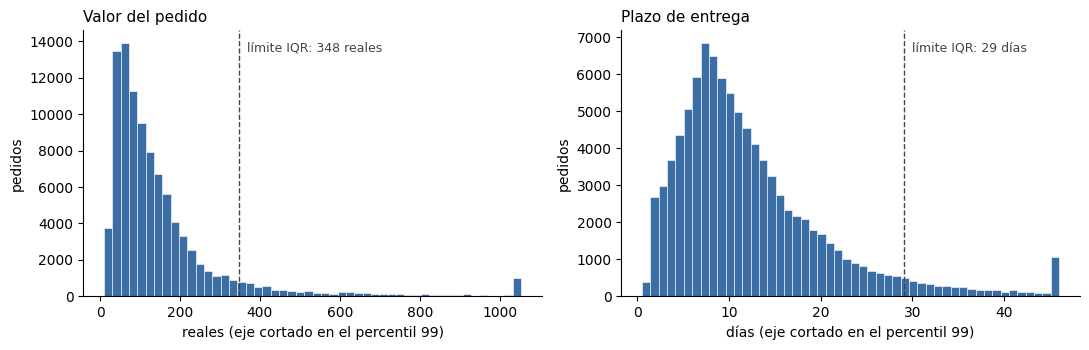

In [12]:
fig, ejes = plt.subplots(1, 2, figsize=(11, 3.6))

for eje, col, lim, titulo, unidad in [
        (ejes[0], "valor_total", lim_valor, "Valor del pedido", "reales"),
        (ejes[1], "dias_entrega", lim_dias, "Plazo de entrega", "días")]:
    tope = pedidos[col].quantile(0.99)                    # el eje se corta en el percentil 99
    eje.hist(pedidos[col].clip(upper=tope), bins=50, color="#3b6ea5", edgecolor="white", linewidth=0.4)
    eje.axvline(lim, color="#444444", linestyle="--", linewidth=1)
    eje.text(lim, eje.get_ylim()[1] * 0.92, f"  límite IQR: {lim:.0f} {unidad}", color="#444444", fontsize=9)
    eje.set_title(titulo, loc="left", fontsize=11)
    eje.set_xlabel(f"{unidad} (eje cortado en el percentil 99)")
    eje.set_ylabel("pedidos")
    eje.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

**Decisión: se conservan todos.** Son pedidos caros y entregas lentas que ocurrieron de verdad.
Quedan marcados con `valor_extremo` y `entrega_extrema` para poder analizar con y sin ellos.
Borrar las entregas lentas eliminaría justo lo que explica las malas valoraciones.

## 9. Comprobaciones finales y guardado

In [13]:
assert pedidos["order_id"].is_unique, "Hay pedidos duplicados"
assert pedidos["n_items"].notna().all(), "Hay pedidos sin productos"
assert (pedidos["dias_entrega"] > 0).all(), "Hay plazos de entrega negativos"

columnas = ["order_id", "customer_unique_id", "customer_city", "customer_state",
            "order_purchase_timestamp", "order_delivered_customer_date", "order_estimated_delivery_date",
            "n_items", "n_vendedores", "categoria_principal",
            "valor_productos", "valor_envio", "valor_total",
            "pago_total", "tipo_pago", "cuotas", "review_score",
            "dias_entrega", "dias_vs_estimado", "con_retraso",
            "fechas_incoherentes", "valor_extremo", "entrega_extrema"]

pedidos[columnas].to_csv("../data/clean/pedidos.csv", index=False)
items.to_csv("../data/clean/items.csv", index=False)
payments.to_csv("../data/clean/pagos.csv", index=False)

print(f"pedidos.csv  {len(pedidos):>8,} filas")
print(f"items.csv    {len(items):>8,} filas")
print(f"pagos.csv    {len(payments):>8,} filas")

pedidos.csv    96,203 filas
items.csv     109,872 filas
pagos.csv     100,465 filas


## 10. Registro de limpieza

In [14]:
pd.DataFrame(registro)

,paso,filas_antes,filas_despues,eliminadas,motivo
0,Periodo ene-2017 a ago-2018,99441,99092,349,Meses de los extremos casi vacíos
1,Solo pedidos entregados,99092,96211,2881,"Cancelados, no disponibles y en curso no son v..."
2,Entregados sin fecha de entrega,96211,96203,8,Estado y fecha se contradicen
3,Items de pedidos fuera del análisis,112650,109872,2778,Se arrastra el filtro de pedidos
4,Valoraciones duplicadas por pedido,99224,98673,551,Se conserva la más reciente
5,Pagos not_defined,103886,103883,3,Importe 0 y tipo desconocido
6,Pagos de pedidos fuera del análisis,103883,100465,3418,Se arrastra el filtro de pedidos


In [15]:
print(f"Clientes únicos:      {pedidos['customer_unique_id'].nunique():,}")
print(f"Ingresos totales:     {pedidos['valor_total'].sum():,.0f} reales")
print(f"Ticket medio:         {pedidos['valor_total'].mean():.2f} reales")
print(f"Pedidos con retraso:  {pedidos['con_retraso'].mean():.1%}")
print(f"Pedidos sin valorar:  {pedidos['review_score'].isna().sum():,}")

Clientes únicos:      93,096
Ingresos totales:     15,376,431 reales
Ticket medio:         159.83 reales
Pedidos con retraso:  8.1%
Pedidos sin valorar:  643
